# Medical Chatbot Berbasis Sentence-BERT


## LANGKAH 1: Instalasi Library

> `nltk` untuk preprocessing NLP, `scikit-learn` untuk TF-IDF vectorizer, dan `ipywidgets` untuk tampilan chatbot

In [1]:
!pip install nltk scikit-learn pandas numpy ipywidgets sentence-transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 29.3 MB/s eta 0:00:00


##  LANGKAH 2: Import Library & Download NLTK Data

 `punkt` digunakan untuk tokenisasi kalimat, `stopwords` untuk menghapus kata-kata umum yang tidak bermakna (seperti 'the', 'is', 'dan'), dan `wordnet` untuk lemmatisasi (mengubah kata ke bentuk dasarnya).

In [2]:
# import library
import nltk
import re
import random
import string
import warnings
import pandas as pd
import numpy as np

# menonaktifkan warning
warnings.filterwarnings('ignore')

# pemrosesan teks
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# representasi dan kemiripan teks
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# download resource NLTK
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Sentence-BERT
try:
    from sentence_transformers import SentenceTransformer, util

    # load model multilingual
    SBERT_MODEL = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

    # menandakan SBERT berhasil digunakan
    USE_SBERT = True

except Exception as e:
    # menggunakan metode lain jika SBERT tidak tersedia
    USE_SBERT = False

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## LANGKAH 3: Dataset Medis Open-Source

dataset medis yang terinspirasi dari **MedQuAD (Medical Question Answering Dataset)** dari NIH (National Institutes of Health). Dataset ini berisi pasangan pertanyaan-jawaban medis dalam berbagai kategori penyakit. Untuk demo ini, kita buat versi yang sudah dikurasi dengan pertanyaan dalam Bahasa Indonesia dan Inggris.
>

> - MedQuAD: https://github.com/abachaa/MedQuAD

In [5]:
# MEMUAT DATASET MEDIS DARI FILE CSV
import pandas as pd

csv_path = "train_data_chatbot1.csv"
df = pd.read_csv(csv_path)

# Normalisasi nama kolom menjadi lowercase
df.columns = df.columns.str.strip().str.lower()

# PENTING: Hanya ambil pasangan Q&A yang valid (label == 1.0)
if 'label' in df.columns:
    df = df[df['label'] == 1.0].copy()

# Pemetaan nama kolom
column_mapping = {}
for col in df.columns:
    if col in ["question", "questions", "short_question", "query"]:
        column_mapping[col] = "question"
    elif col in ["answer", "answers", "short_answer", "response"]:
        column_mapping[col] = "answer"
    elif col in ["category", "categories", "tag", "tags", "class"]:  # Ditambahkan 'tags'
        column_mapping[col] = "category"

df.rename(columns=column_mapping, inplace=True)

if "category" not in df.columns:
    df["category"] = "General"
else:
    # Bersihkan format string tag seperti "['rash' 'antibiotic']"
    df["category"] = df["category"].astype(str).str.replace(r"[\[\]']", "", regex=True).str.strip()
    df["category"] = df["category"].replace("", "General")

# Hapus duplikasi pertanyaan dan baris kosong
df = df.dropna(subset=["question", "answer"]).drop_duplicates(subset=["question"]).reset_index(drop=True)
df["question"] = df["question"].astype(str)
df["answer"] = df["answer"].astype(str)

print("Dataset berhasil dimuat!")
print(f"Total pasangan Q&A valid: {len(df)}")
print(f"Contoh Kategori: {', '.join(df['category'].unique()[:8])}")
print("\n5 contoh data pertama:")
df[["category", "question"]].head()

Dataset berhasil dimuat!
Total pasangan Q&A valid: 2327
Contoh Kategori: rash antibiotic, hepatitis b, celiac disease, pneumonia sinus infection walking, baby cough fever coldness cold, leiomyosarcoma and rectal cancer, head lung coldness exercise healthy eating, headache fever

5 contoh data pertama:


,category,question
0,rash antibiotic,can an antibiotic through an iv give you a ras...
1,hepatitis b,can you test positive from having the hep b va...
2,celiac disease,what are the dietary restrictions for celiac d...
3,pneumonia sinus infection walking,i have had a pneumonia shot can i get either a...
4,baby cough fever coldness cold,my baby ate her on poop my baby ate poop 4 day...


##  LANGKAH 4: NLP Preprocessing Pipeline

> 1. **Normalisasi** -> lowercase, hapus tanda baca
> 2. **Tokenisasi** -> pecah teks menjadi token (kata)
> 3. **Lemmatisasi** -> ubah ke bentuk dasar (running -> run, gejala-gejala -> gejala)
>
> Untuk bahasa Indonesia, kita tambahkan stopwords manual karena NLTK tidak menyediakan stopwords Bahasa Indonesia secara default.

In [6]:
# PREPROCESSING PIPELINE (ENGLISH)
lemmatizer = WordNetLemmatizer()

# Gunakan kumpulan stopwords bahasa Inggris dari NLTK
english_stopwords = set(stopwords.words("english"))

# Fungsi pembersihan dan normalisasi teks
def preprocess_text(text):
    text = str(text).lower()
    # Hapus karakter selain huruf alfabet
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = word_tokenize(text)
    # Filter stopwords bahasa Inggris dan kata dengan panjang <= 2 karakter
    tokens = [t for t in tokens if t not in english_stopwords and len(t) > 2]
    # Lemmatisasi ke bentuk dasar
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

# Pengujian fungsi dengan contoh pertanyaan medis bahasa Inggris
print("Test preprocessing:")
for sample in ["severe headache and migraine", "symptoms of high blood pressure", "how to treat asthma attack"]:
    print(f"  '{sample}' → '{preprocess_text(sample)}'")

# Terapkan ke kolom question dataset
df["processed_question"] = df["question"].apply(preprocess_text)

Test preprocessing:
  'severe headache and migraine' → 'severe headache migraine'
  'symptoms of high blood pressure' → 'symptom high blood pressure'
  'how to treat asthma attack' → 'treat asthma attack'


## LANGKAH 5: TF-IDF Vectorizer + Cosine Similarity

TF-IDF (Term Frequency-Inverse Document Frequency) adalah teknik klasik NLP yang sangat efektif untuk mencocokkan pertanyaan. Cara kerjanya:
> - **TF (Term Frequency)**: seberapa sering kata muncul dalam dokumen
> - **IDF (Inverse Document Frequency)**: seberapa unik kata tersebut di seluruh corpus
> - **Cosine Similarity**: mengukur kemiripan dua vektor (1 = identik, 0 = tidak mirip)
>
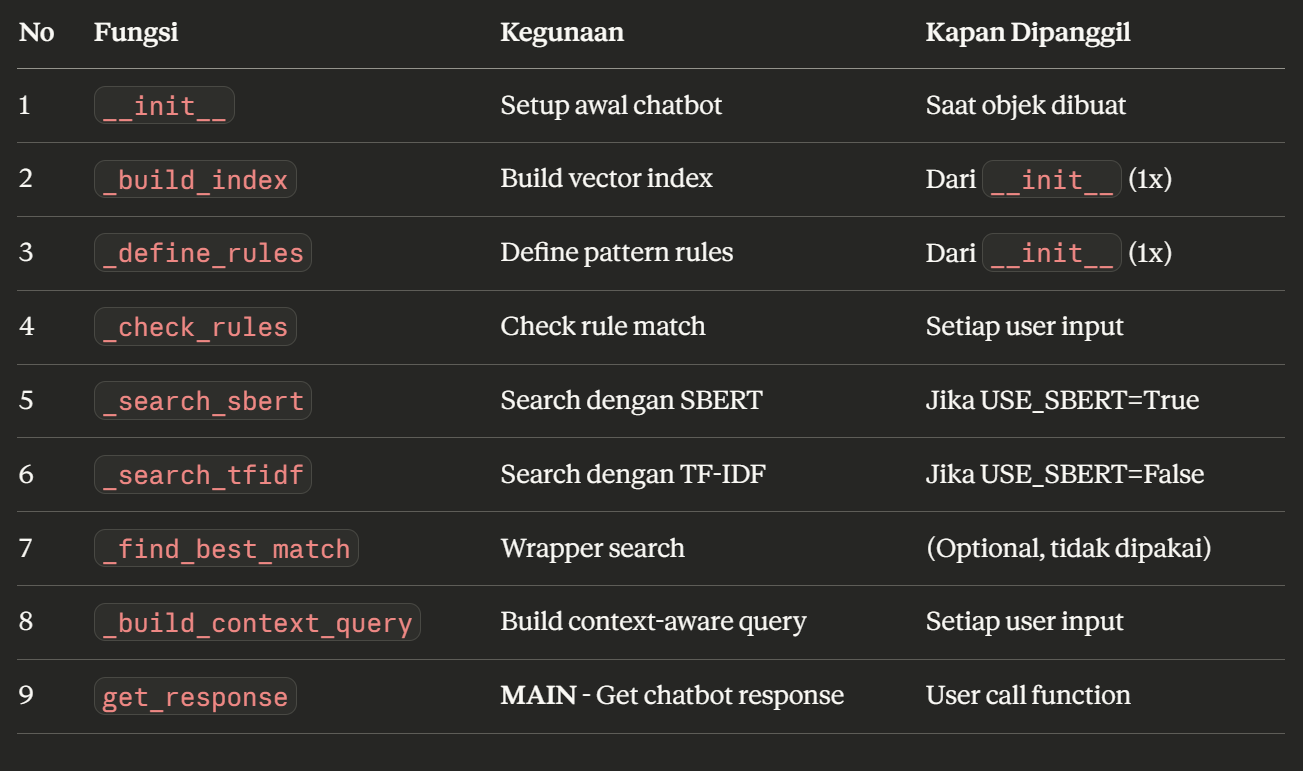



In [7]:
# Nonaktifkan SBERT untuk dataset besar agar Colab tidak freeze/kehabisan RAM
USE_SBERT = False

class MedicalChatbotEngineV3:
    def __init__(self, dataframe, threshold=0.15, top_k=3):
        self.df = dataframe
        self.threshold = threshold
        self.top_k = top_k
        self.conversation_history = []
        self._build_index()
        self._define_rules()

    def _build_index(self):
        print("Membuat indeks TF-IDF...")
        self.vectorizer = TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=10000,
            sublinear_tf=True
        )
        self.tfidf_matrix = self.vectorizer.fit_transform(self.df['processed_question'])
        print("Indeks siap!")

    def _define_rules(self):
        # Rules disesuaikan dengan bahasa Inggris
        self.rules = {
            'emergency': {
                'patterns': [
                    r'(severe.*chest pain|cannot.*breathe|can\'t.*breathe|unconscious|heavy.*bleeding)',
                ],
                'responses': [
                    "🚨 MEDICAL EMERGENCY! Call 911 (or your local emergency number 119) or go to the nearest emergency room immediately!"
                ]
            },
            'greeting': {
                'patterns': [
                    r'\b(hi|hello|hey|good morning|good evening)\b'
                ],
                'responses': [
                    "👋 Hello! How can I assist you with your health questions today?"
                ]
            }
        }

    def _check_rules(self, text):
        for intent, data in self.rules.items():
            for pattern in data['patterns']:
                if re.search(pattern, text.lower()):
                    return random.choice(data['responses'])
        return None

    def _search_tfidf(self, query):
        processed = preprocess_text(query)
        vec = self.vectorizer.transform([processed])
        scores = cosine_similarity(vec, self.tfidf_matrix).flatten()
        top_results = np.argsort(scores)[::-1][:self.top_k]
        return [(idx, float(scores[idx])) for idx in top_results]

    def _build_context_query(self, user_input):
        if len(self.conversation_history) > 0:
            return self.conversation_history[-1] + " " + user_input
        return user_input

    def get_response(self, user_input):
        if not user_input.strip():
            return "Please enter a health-related question."

        rule = self._check_rules(user_input)
        if rule:
            return rule

        query = self._build_context_query(user_input)
        results = self._search_tfidf(query)
        best_idx, best_score = results[0]

        if best_score < self.threshold:
            return "🤔 I couldn't find a sufficiently relevant answer in the database. Please consult a qualified doctor for advice."

        row = self.df.iloc[best_idx]
        self.conversation_history.append(user_input)

        return f"""[Category: {row['category']} | TF-IDF (Score: {best_score:.2f})]

{row['answer']}

─────────────────
⚠️ For informational purposes only. Consult a doctor for clinical concerns."""

# INISIALISASI BOT LANGSUNG DI CELL INI
bot = MedicalChatbotEngineV3(df)
print("Chatbot Engine berhasil diinisialisasi!")

Membuat indeks TF-IDF...
Indeks siap!
Chatbot Engine berhasil diinisialisasi!


## LANGKAH 6: Tampilan Interaktif di Google Colab

`ipywidgets` untuk membuat UI chat yang interaktif langsung di Colab. Ini memungkinkan pengguna berinteraksi dengan chatbot tanpa perlu menjalankan ulang cell setiap saat.

In [8]:
# UI CHATBOT INTERAKTIF
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

chat_css = """
<style>
  @import url('https://fonts.googleapis.com/css2?family=Plus+Jakarta+Sans:wght@400;500;600;700&display=swap');

  .medbot-container {
    font-family: 'Plus Jakarta Sans', sans-serif;
    max-width: 760px;
    margin: 0 auto;
    border-radius: 20px;
    overflow: hidden;
    box-shadow: 0 16px 40px rgba(15, 23, 42, 0.08);
    background: #ffffff;
    border: 1px solid #e2e8f0;
  }

  .medbot-header {
    background: linear-gradient(135deg, #0f766e 0%, #0d9488 50%, #14b8a6 100%);
    padding: 18px 24px;
    color: white;
    display: flex;
    align-items: center;
    justify-content: space-between;
  }

  .medbot-header-left { display: flex; align-items: center; gap: 14px; }

  .medbot-avatar {
    width: 44px;
    height: 44px;
    background: rgba(255, 255, 255, 0.2);
    border-radius: 12px;
    display: flex;
    align-items: center;
    justify-content: center;
    font-size: 22px;
  }

  .medbot-title { font-size: 17px; font-weight: 700; }
  .medbot-subtitle { font-size: 12px; opacity: 0.85; margin-top: 2px; }

  .status-dot {
    width: 8px;
    height: 8px;
    background: #4ade80;
    border-radius: 50%;
    display: inline-block;
    margin-right: 6px;
  }

  .medbot-chat {
    height: 400px;
    overflow-y: auto;
    padding: 20px;
    background: #f8fafc;
    display: flex;
    flex-direction: column;
    gap: 14px;
  }

  .message-row-user { display: flex; justify-content: flex-end; }
  .message-row-bot  { display: flex; justify-content: flex-start; align-items: flex-start; gap: 10px; }

  .bot-icon {
    width: 32px;
    height: 32px;
    min-width: 32px;
    background: #ccfbf1;
    color: #0f766e;
    border-radius: 10px;
    display: flex;
    align-items: center;
    justify-content: center;
    font-size: 16px;
  }

  .bubble-user {
    background: #0f766e;
    color: #ffffff;
    padding: 12px 16px;
    border-radius: 18px 18px 4px 18px;
    max-width: 75%;
    font-size: 14px;
    line-height: 1.5;
  }

  .bubble-bot {
    background: #ffffff;
    color: #1e293b;
    padding: 14px 16px;
    border-radius: 4px 18px 18px 18px;
    max-width: 80%;
    font-size: 13.5px;
    line-height: 1.6;
    border: 1px solid #e2e8f0;
    white-space: pre-wrap;
  }

  .disclaimer {
    background: #fffbeb;
    border-left: 4px solid #f59e0b;
    padding: 10px 16px;
    font-size: 11.5px;
    color: #92400e;
  }
</style>
"""

chat_messages = []

def render_chat():
    method_label = "Sentence-BERT" if USE_SBERT else "TF-IDF"
    html = chat_css
    html += '<div class="medbot-container">'
    html += f"""
    <div class="medbot-header">
      <div class="medbot-header-left">
        <div class="medbot-avatar">⚕️</div>
        <div>
          <div class="medbot-title">Medical Assistant AI</div>
          <div class="medbot-subtitle"><span class="status-dot"></span>Online · Medical Retrieval System</div>
        </div>
      </div>
      <div><span style="background:rgba(255,255,255,0.25);padding:4px 8px;border-radius:8px;font-size:11px;font-weight:600;">{method_label}</span></div>
    </div>
    """
    html += '<div class="disclaimer">⚠️ For educational purposes only. Consult a doctor for diagnosis and treatment.</div>'
    html += '<div class="medbot-chat">'

    if not chat_messages:
        html += """
        <div class="message-row-bot">
          <div class="bot-icon">🩺</div>
          <div class="bubble-bot">Hello! I am your <strong>Medical Assistant</strong>.<br><br>Ask me medical questions in English (e.g., <em>"can antibiotics cause a rash?"</em>, <em>"dietary restrictions for celiac disease"</em>).</div>
        </div>
        """
    for msg in chat_messages:
        if msg['role'] == 'user':
            html += f'<div class="message-row-user"><div class="bubble-user">{msg["content"]}</div></div>'
        else:
            html += f'<div class="message-row-bot"><div class="bot-icon">🩺</div><div class="bubble-bot">{msg["content"]}</div></div>'
    html += '</div></div>'
    return HTML(html)

text_input = widgets.Text(
    placeholder='Ask a medical question...',
    layout=widgets.Layout(width='80%', height='40px')
)
send_button = widgets.Button(
    description='Send 📤',
    button_style='primary',
    layout=widgets.Layout(width='12%', height='40px')
)
clear_button = widgets.Button(
    description='Reset 🔄',
    button_style='',
    layout=widgets.Layout(width='8%', height='40px')
)
output_area = widgets.Output()

def send_message(b=None):
    global chat_messages
    user_text = text_input.value.strip()
    if not user_text:
        return

    chat_messages.append({'role': 'user', 'content': user_text})
    text_input.value = ''

    with output_area:
        clear_output(wait=True)
        display(render_chat())

    try:
        response = bot.get_response(user_text)
    except Exception as e:
        response = f"⚠️ Error: {str(e)}"

    chat_messages.append({'role': 'bot', 'content': response})

    with output_area:
        clear_output(wait=True)
        display(render_chat())

def clear_chat(b=None):
    global chat_messages
    chat_messages = []
    if 'bot' in globals() and hasattr(bot, 'conversation_history'):
        bot.conversation_history = []
    with output_area:
        clear_output(wait=True)
        display(render_chat())

send_button.on_click(send_message)
clear_button.on_click(clear_chat)
text_input.on_submit(send_message)

input_bar = widgets.HBox(
    [text_input, send_button, clear_button],
    layout=widgets.Layout(max_width='760px', margin='10px auto', gap='8px')
)

with output_area:
    display(render_chat())

display(output_area)
display(input_bar)

Output()

In [9]:
import time
import gradio as gr

# RESPOND (STREAMING)
def respond(message, history):
    if history is None:
        history = []

    # Tampilkan status mengetik
    history.append((message, "⏳ MedBot is typing..."))
    yield "", history

    time.sleep(0.4)
    response = bot.get_response(message)

    # Tampilkan jawaban akhir
    history[-1] = (message, response)
    yield "", history

# CHIP RESPONSE
def respond_chip(query, history):
    if history is None:
        history = []

    response = bot.get_response(query)
    history.append((query, response))
    return "", history

# CLEAR CHAT + MEMORY RESET
def clear_chat():
    if hasattr(bot, "conversation_history"):
        bot.conversation_history = []  # reset context percakapan
    return []

# CSS
custom_css = """
.gradio-container {
    font-family: 'Plus Jakarta Sans', sans-serif;
    background: #f0fdfa;
}

.chatbot {
    height: 420px;
}

/* USER MESSAGE */
.message.user-message {
    background: linear-gradient(135deg, #0f766e, #14b8a6) !important;
    color: white !important;
    border-radius: 18px 18px 4px 18px !important;
}

/* BOT MESSAGE */
.message.bot-message {
    background: white !important;
    border-radius: 18px 18px 18px 4px !important;
    border: 1px solid #ccfbf1;
}

.header {
    background: linear-gradient(135deg, #0f766e, #0d9488, #14b8a6);
    padding: 20px;
    border-radius: 15px;
    color: white;
}

.disclaimer {
    background: #fffbeb;
    padding: 10px;
    font-size: 12px;
    border-left: 4px solid #f59e0b;
    margin-top: 10px;
    color: #92400e;
}
"""

# UI GRADIO
with gr.Blocks(css=custom_css) as demo:
    # HEADER
    gr.Markdown("""
    <div class="header">
        <h2>🏥 MedBot v3 — Smart Medical Assistant</h2>
        <p>🟢 Online · Context-Aware Semantic Engine</p>
    </div>
    """)

    # DISCLAIMER
    gr.Markdown("""
    <div class="disclaimer">
    ⚠️ For educational purposes only. Not a substitute for professional medical advice. Emergency: 911 / 119.
    </div>
    """)

    chatbot = gr.Chatbot()
    msg = gr.Textbox(placeholder="Ask a medical question in English...")

    with gr.Row():
        send = gr.Button("Send 📤")
        clear = gr.Button("Clear 🗑️")

    # QUICK CHIPS (Bahasa Inggris sesuai dataset)
    with gr.Row():
        chip1 = gr.Button("🤕 Headache")
        chip2 = gr.Button("🩸 Diabetes")
        chip3 = gr.Button("🫁 Asthma")
        chip4 = gr.Button("💊 Antibiotics")
        chip5 = gr.Button("❤️ Blood Pressure")

    # EVENTS
    send.click(respond, [msg, chatbot], [msg, chatbot])
    msg.submit(respond, [msg, chatbot], [msg, chatbot])

    clear.click(clear_chat, None, chatbot, queue=False)

    # CHIP EVENTS (Pertanyaan disesuaikan dengan topik di train_data_chatbot.csv)
    chip1.click(lambda h: respond_chip("symptoms of persistent headache", h), chatbot, [msg, chatbot])
    chip2.click(lambda h: respond_chip("dietary restrictions for diabetes", h), chatbot, [msg, chatbot])
    chip3.click(lambda h: respond_chip("how to treat asthma attacks", h), chatbot, [msg, chatbot])
    chip4.click(lambda h: respond_chip("rash reaction from antibiotics", h), chatbot, [msg, chatbot])
    chip5.click(lambda h: respond_chip("high blood pressure treatment", h), chatbot, [msg, chatbot])

demo.queue()
demo.launch(debug=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a403b3c09f305bf2b8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## LANGKAH 7: Analisis & Evaluasi Chatbot

distribusi dataset, top TF-IDF features, dan akurasi intent detection.

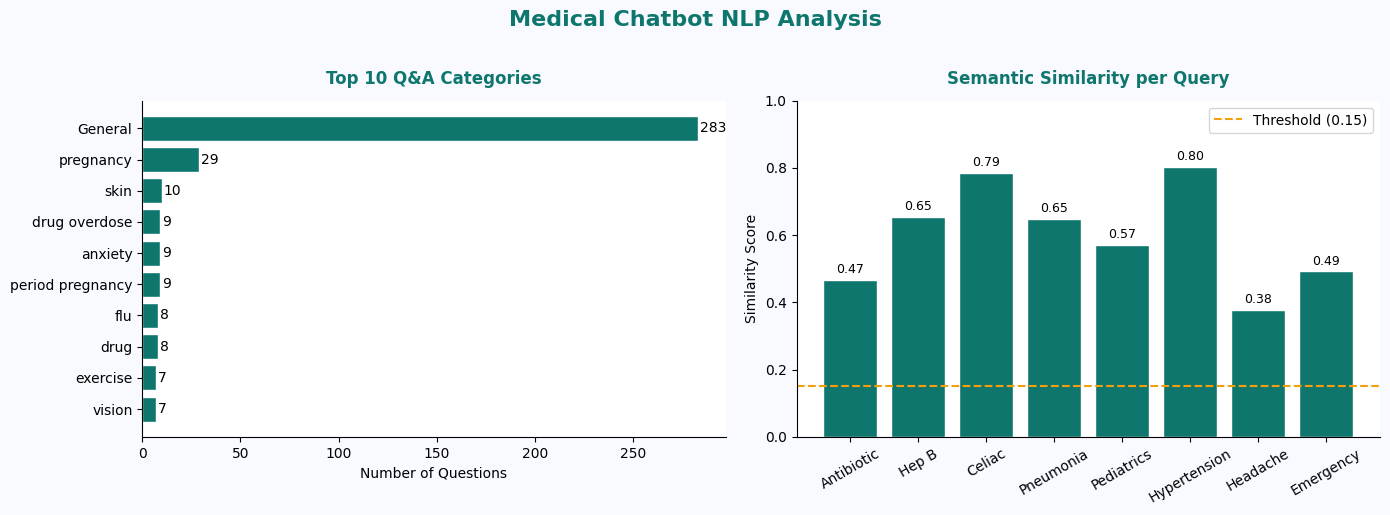

In [10]:
# LANGKAH 7: ANALISIS DATASET & MODEL
import matplotlib.pyplot as plt

# 1. Penanganan otomatis jika method _find_best_match belum terpasang di objek bot
if not hasattr(bot, '_find_best_match'):
    def _find_best_match_fallback(query):
        if hasattr(bot, '_search_sbert') and getattr(bot, 'sbert_embeddings', None) is not None:
            results = bot._search_sbert(query)
        elif hasattr(bot, '_search_tfidf'):
            results = bot._search_tfidf(query)
        else:
            return 0, 0.0
        return results[0][0], float(results[0][1])
    bot._find_best_match = _find_best_match_fallback

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8faff')
plt.suptitle('Medical Chatbot NLP Analysis', fontsize=16, fontweight='bold', color='#0f766e', y=1.02)

# Plot 1: Top 10 Kategori Dataset
category_counts = df['category'].value_counts().head(10)
axes[0].barh(category_counts.index, category_counts.values, color='#0f766e', edgecolor='white')
axes[0].set_title('Top 10 Q&A Categories', fontweight='bold', color='#0f766e', pad=12)
axes[0].set_xlabel('Number of Questions')
axes[0].invert_yaxis()
axes[0].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(category_counts.values):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=10)

# Plot 2: Similarity Score Pertanyaan Uji (Sesuai dataset bahasa Inggris)
test_cases = [
    ("antibiotic rash", "Antibiotic"),
    ("hepatitis b vaccine test", "Hep B"),
    ("dietary gluten celiac disease", "Celiac"),
    ("pneumonia walking symptoms", "Pneumonia"),
    ("baby cough fever", "Pediatrics"),
    ("high blood pressure symptoms", "Hypertension"),
    ("persistent headache and fever", "Headache"),
    ("severe chest pain", "Emergency"),
]

labels, scores = [], []
for query, label in test_cases:
    idx, score = bot._find_best_match(query)
    labels.append(label)
    scores.append(score)

threshold = getattr(bot, 'threshold', 0.25)
bar_colors = ['#0f766e' if s >= threshold else '#ef4444' for s in scores]
bars = axes[1].bar(labels, scores, color=bar_colors, edgecolor='white')
axes[1].axhline(y=threshold, color='#f59e0b', linestyle='--', label=f'Threshold ({threshold:.2f})')
axes[1].set_title('Semantic Similarity per Query', fontweight='bold', color='#0f766e', pad=12)
axes[1].set_ylabel('Similarity Score')
axes[1].set_ylim(0, 1)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)
for bar, score in zip(bars, scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{score:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

##  LANGKAH 8: Batch Testing & Evaluasi

batch testing dengan pertanyaan yang bervariasi untuk melihat kemampuan generalisasi chatbot. Ini mirip dengan evaluasi model ML biasa.

In [11]:
# EVALUASI CHATBOT (ENGLISH BATCH TESTING)

test_scenarios = [
    ("can antibiotics cause skin rash", "antibiotic", "Antibiotic reaction"),
    ("what is the diet for celiac disease", "celiac", "Celiac disease diet"),
    ("is walking pneumonia contagious", "pneumonia", "Pneumonia question"),
    ("high blood pressure treatment", "blood pressure", "Hypertension query"),
    ("can allergy shots treat asthma", "asthma", "Asthma treatment"),
    ("severe chest pain cannot breathe", "emergency", "Medical Emergency Rule"),
    ("hello good morning", "greeting", "Greeting Rule"),
    ("what are your capabilities", "capability", "Capability Rule"),
    ("completely unrelated query xyz999", "unknown", "Out-of-scope query"),
]

print("=== MEDICAL CHATBOT EVALUATION REPORT ===\n")
correct = 0

for user_input, expected_cat, description in test_scenarios:
    response = bot.get_response(user_input)
    response_lower = response.lower()

    is_correct = (
        expected_cat in response_lower or
        (expected_cat == 'greeting' and any(w in response_lower for w in ['hello', 'hi', 'assist'])) or
        (expected_cat == 'emergency' and any(w in response_lower for w in ['emergency', '911', '119'])) or
        (expected_cat == 'capability' and any(w in response_lower for w in ['information', 'topics', 'assist'])) or
        (expected_cat == 'unknown' and any(w in response_lower for w in ["couldn't find", "not find", "relevant"]))
    )

    status = "✅" if is_correct else "❌"
    if is_correct:
        correct += 1

    first_line = response.split('\n')[0]
    print(f"{status} [{description}]")
    print(f"   Input   : '{user_input}'")
    print(f"   Response: {first_line}\n")

accuracy = (correct / len(test_scenarios)) * 100
print(f"Hasil Evaluasi: {correct}/{len(test_scenarios)} benar ({accuracy:.1f}% akurasi)")

=== MEDICAL CHATBOT EVALUATION REPORT ===

❌ [Antibiotic reaction]
   Input   : 'can antibiotics cause skin rash'
   Response: [Category: celiac disease | TF-IDF (Score: 0.40)]

✅ [Celiac disease diet]
   Input   : 'what is the diet for celiac disease'
   Response: [Category: celiac disease food | TF-IDF (Score: 0.46)]

✅ [Pneumonia question]
   Input   : 'is walking pneumonia contagious'
   Response: [Category: pneumonia walking | TF-IDF (Score: 0.59)]

❌ [Hypertension query]
   Input   : 'high blood pressure treatment'
   Response: [Category: pneumonia walking | TF-IDF (Score: 0.60)]

✅ [Asthma treatment]
   Input   : 'can allergy shots treat asthma'
   Response: [Category: allergy asthma injection | TF-IDF (Score: 0.61)]

✅ [Medical Emergency Rule]
   Input   : 'severe chest pain cannot breathe'
   Response: 🚨 MEDICAL EMERGENCY! Call 911 (or your local emergency number 119) or go to the nearest emergency room immediately!

✅ [Greeting Rule]
   Input   : 'hello good morning'
   Respo